In [2]:
# Linear Regression using Deep Neural Network (Boston Housing Dataset)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# Load Dataset
df = pd.read_csv("BostonHousing.csv")

In [4]:
# Display first 5 rows
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [5]:
# Features and Target
X = df.drop("medv", axis=1)
y = df["medv"]

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Build Deep Neural Network Model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [10]:
# Train Model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 598.2735 - mae: 22.4709 - val_loss: 516.8068 - val_mae: 21.0986
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 542.5384 - mae: 21.1010 - val_loss: 442.1785 - val_mae: 19.1502
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 429.9236 - mae: 18.1492 - val_loss: 286.3817 - val_mae: 14.8913
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 222.0908 - mae: 12.4496 - val_loss: 92.9178 - val_mae: 7.7192
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 85.5202 - mae: 7.3623 - val_loss: 39.5888 - val_mae: 4.5330
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 46.6964 - mae: 5.2991 - val_loss: 29.3934 - val_mae: 3.6334
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 31.2039 - mae: 4.1620 - val_loss: 26.0524 - val_mae: 3.4730
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25.5687 - mae: 3.8040 - val_loss: 25.1196 - val_mae: 3.4440
Epoch 9/100
21/21 ━━━━━━━━━━━━

In [11]:
# Predictions
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [13]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


Model Evaluation
MSE : 11.174633014695134
RMSE : 3.3428480394261317
R2 Score : 0.8476195754108982


In [14]:
# Compare Actual vs Predicted

results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.flatten()})
print("\nActual vs Predicted Values")
print(results.head(10))


Actual vs Predicted Values
   Actual  Predicted
0    23.6  27.806450
1    32.4  35.901104
2    13.6  16.558001
3    22.8  23.582153
4    16.1  14.685477
5    20.0  19.887201
6    17.8  17.079859
7    14.0  13.311680
8    19.6  25.234856
9    16.8  18.079678


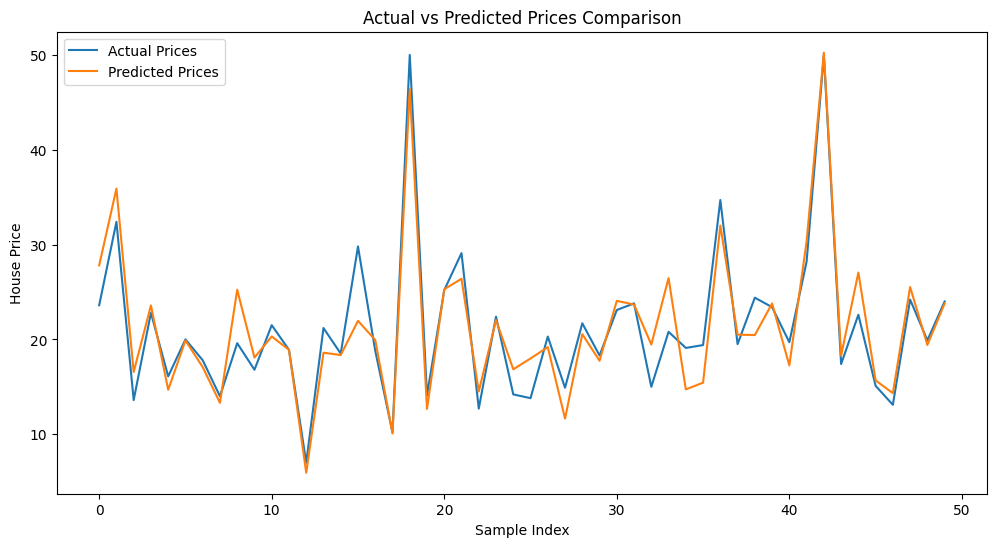

In [16]:
# Line Plot Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:50], label='Actual Prices')
plt.plot(y_pred[:50], label='Predicted Prices')

plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Prices Comparison")

plt.legend()
plt.show()